# House Price Prediction

## Phase 1: Load and Inspect the Dataset 

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [68]:
df = pd.read_csv("house_prices.csv")

In [69]:
df.shape

(187531, 21)

In [70]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [72]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [73]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')

In [74]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 187531
Number of Columns: 21


In [75]:
df.dtypes

Index                  int64
Title                    str
Description              str
Amount(in rupees)        str
Price (in rupees)    float64
location                 str
Carpet Area              str
Status                   str
Floor                    str
Transaction              str
Furnishing               str
facing                   str
overlooking              str
Society                  str
Bathroom                 str
Balcony                  str
Car Parking              str
Ownership                str
Super Area               str
Dimensions           float64
Plot Area            float64
dtype: object

In [76]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numeric Columns:")
print(numeric_columns)

Numeric Columns:
Index(['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area'], dtype='str')


In [77]:
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area',
       'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking',
       'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership',
       'Super Area'],
      dtype='str')


In [78]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [79]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
dtype: float64

In [80]:
df.describe(include='all')

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
count,187531.000000,187531,184508,187531,1.698660e+05,187531,106858,186916,180454,187448,...,117298,106095,77853,186703,138596,84174,122014,79846,0.0,0.0
unique,NaN,32446,65634,1561,NaN,81,2758,1,947,4,...,8,19,10376,11,11,229,4,2976,NaN,NaN
top,NaN,2 BHK Ready to Occupy Flat for sale in Divyasr...,Multistorey apartment is available for sale. I...,Call for Price,NaN,new-delhi,1000 sqft,Ready to Move,2 out of 4,Resale,...,East,Main Road,Hamdam Apartment,2,2,1 Covered,Freehold,1100 sqft,NaN,NaN
freq,NaN,2106,2732,9684,NaN,27599,5285,186916,12433,144172,...,54741,32193,1648,93007,51809,38754,112229,2599,NaN,NaN
mean,93765.000000,NaN,NaN,NaN,7.583772e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,54135.681003,NaN,NaN,NaN,2.724171e+04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,46882.500000,NaN,NaN,NaN,4.297000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,93765.000000,NaN,NaN,NaN,6.034000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,140647.500000,NaN,NaN,NaN,9.450000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Inspection

### Summary

- Number of Rows: **187,531**
- Number of Columns: **21**
- The dataset contains both numerical and categorical features.
- Numerical columns include:
  - Index
  - Price (in rupees)
  - Dimensions
  - Plot Area
- Most of the features are categorical (text).
- Several columns contain missing values, especially:
  - Dimensions
  - Plot Area
  - Society
  - Super Area
  - Car Parking
  - Carpet Area

# Data Cleaning and Feature Engineering

In [81]:
def parse_amount(x):
    if not isinstance(x, str):
        return np.nan

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 10000000

        return float(x.replace(",", ""))

    except ValueError:
        return np.nan

In [82]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

In [83]:
df["price_clean"].head()

0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: price_clean, dtype: float64

In [84]:
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

In [85]:
df = df.dropna(subset=["price_clean"])

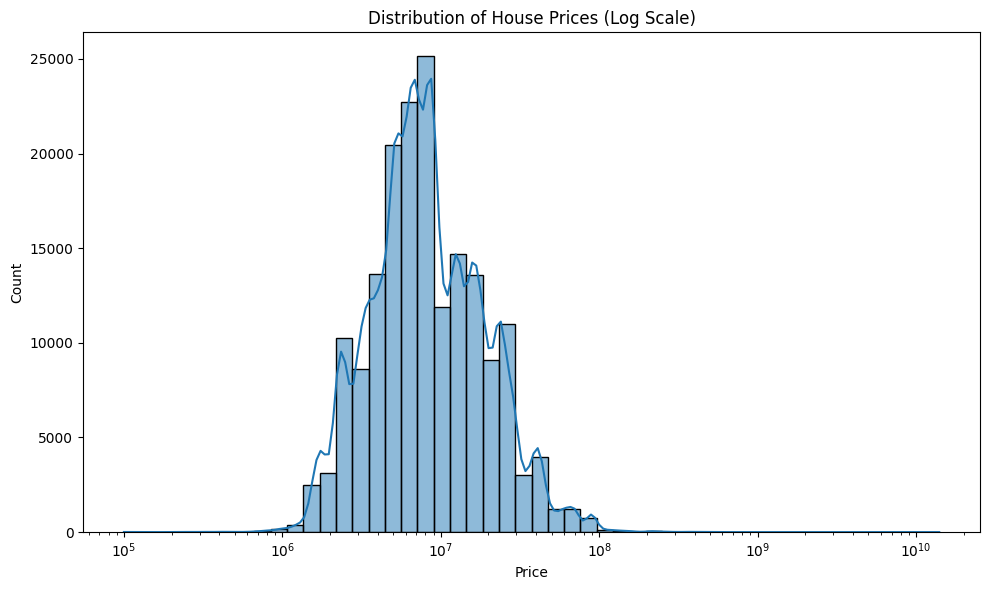

In [86]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price_clean"],
    bins=50,
    log_scale=True,
    kde=True
)

plt.title("Distribution of House Prices (Log Scale)")
plt.xlabel("Price")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation

- House prices exhibit a highly right-skewed distribution.
- Most properties are concentrated in the lower price range.
- A relatively small number of luxury properties create a long right tail.
- Applying a logarithmic scale improves the visualization by compressing extreme values and revealing the overall distribution more clearly.

In [87]:
import re

def extract_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).strip().lower()

    match = re.search(r"(\d+\.?\d*)", area)

    if match:

        value = float(match.group(1))

        if "sqm" in area:
            value *= 10.764

        return round(value,2)

    return np.nan

In [88]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(extract_area)

In [89]:
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1235.758910
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

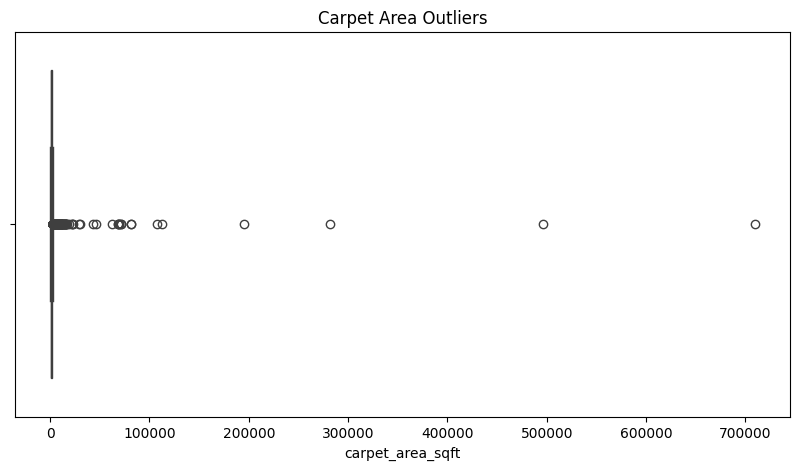

In [90]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["carpet_area_sqft"])

plt.title("Carpet Area Outliers")

plt.show()

In [91]:
df["carpet_area_sqft"].skew()

np.float64(163.85921817817916)

### Observation

- Carpet area is highly right-skewed.
- Most properties have relatively small carpet areas.
- Several extremely large values are present, indicating potential outliers.
- These outliers will be handled during the data preprocessing stage before model training.

## Price vs Carpet Area

In [92]:
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1235.758910
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

In [93]:
df = df[df["carpet_area_sqft"] <= 10000]

In [94]:
df["carpet_area_sqft"].describe()

count    101474.000000
mean       1205.721176
std         733.358697
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max       10000.000000
Name: carpet_area_sqft, dtype: float64

In [95]:
print("Skewness =", df["carpet_area_sqft"].skew())

Skewness = 2.0490523391047146


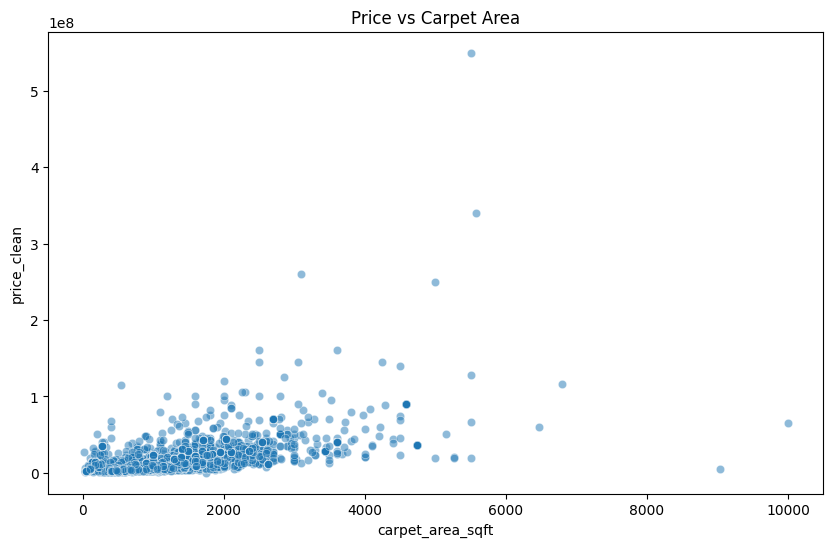

In [96]:
sample_df = df.sample(10000, random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.5
)

plt.title("Price vs Carpet Area")
plt.show()

### Observation

Most properties have carpet areas below 3,000 sqft, while a small number of extremely large properties were identified as outliers.

After removing unrealistic values above 10,000 sqft, the distribution became more representative of the dataset, making the relationship between carpet area and house price easier to analyze.

## Average Price by Top 15 Locations

In [97]:
location_stats = (
    df.groupby("location")
      .agg(
          average_price=("price_clean", "mean"),
          properties=("price_clean", "count")
      )
)

location_stats = location_stats[location_stats["properties"] >= 100]

In [98]:
top_locations = (
    location_stats
    .sort_values("average_price", ascending=False)
    .head(15)
)

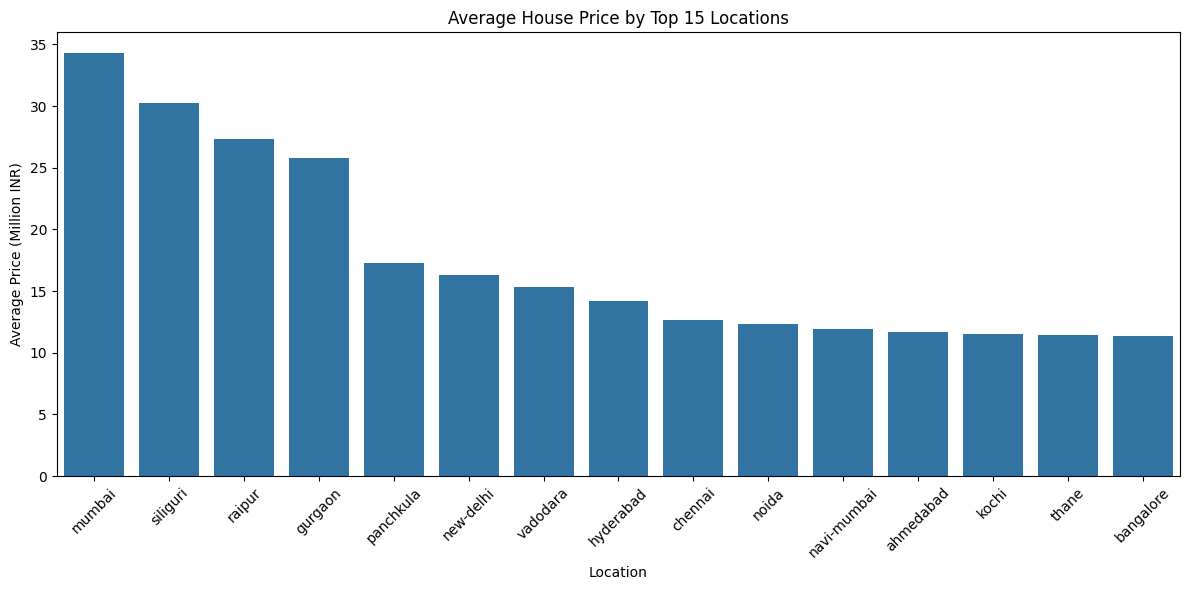

In [99]:
top_locations["average_price"] = top_locations["average_price"] / 1e6

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_locations,
    x=top_locations.index,
    y="average_price"
)

plt.xticks(rotation=45)

plt.title("Average House Price by Top 15 Locations")
plt.xlabel("Location")
plt.ylabel("Average Price (Million INR)")

plt.tight_layout()
plt.show()

### Observation

Average house prices vary considerably across different locations. Major metropolitan areas such as Mumbai and Siliguri have the highest average prices, while other cities show relatively lower averages.

To ensure reliable comparisons, only locations with at least 100 properties were included in the analysis.

## Price by Furnishing Status

In [100]:
df["log_price"] = np.log1p(df["price_clean"])

In [101]:
df[["price_clean", "log_price"]].head()

,price_clean,log_price
0,4200000.0,15.250595
1,9800000.0,16.097893
2,14000000.0,16.454568
3,2500000.0,14.731802
4,16000000.0,16.588099


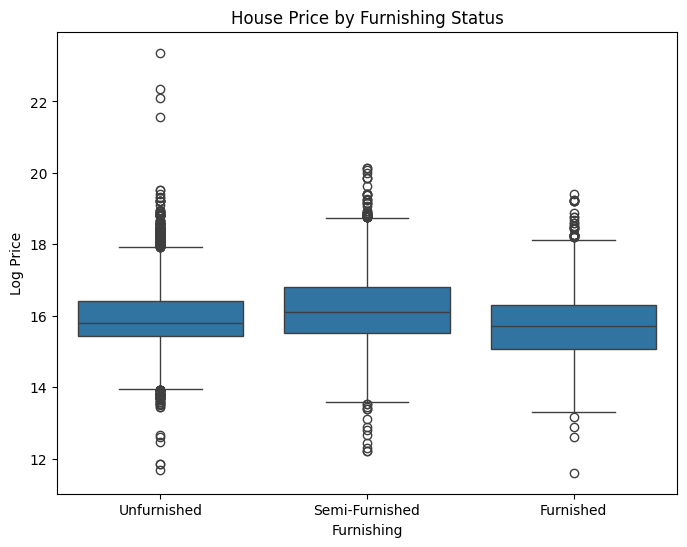

In [102]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="log_price"
)

plt.title("House Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Log Price")

plt.show()

### Observation

House prices vary slightly across furnishing categories. Semi-Furnished properties show the highest median log price, while Furnished and Unfurnished properties have similar distributions. However, there is substantial overlap between all categories, suggesting that furnishing status alone is not a strong predictor of house price.

In [103]:
df[["Dimensions", "Plot Area"]].isnull().sum()

Dimensions    101474
Plot Area     101474
dtype: int64

In [104]:
df.drop(columns=["Dimensions", "Plot Area"], inplace=True)

In [105]:
df.drop(columns=["Index"], inplace=True, errors="ignore")

In [106]:
df.drop(columns=["Title", "Description"], inplace=True)

In [107]:
df.drop(columns=["Amount(in rupees)"], inplace=True, errors="ignore")

In [108]:
df.info()

<class 'pandas.DataFrame'>
Index: 101474 entries, 0 to 187528
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price (in rupees)  93586 non-null   float64
 1   location           101474 non-null  str    
 2   Carpet Area        101474 non-null  str    
 3   Status             101398 non-null  str    
 4   Floor              99289 non-null   str    
 5   Transaction        101410 non-null  str    
 6   Furnishing         101449 non-null  str    
 7   facing             82003 non-null   str    
 8   overlooking        74922 non-null   str    
 9   Society            50545 non-null   str    
 10  Bathroom           101454 non-null  str    
 11  Balcony            94633 non-null   str    
 12  Car Parking        59675 non-null   str    
 13  Ownership          83471 non-null   str    
 14  Super Area         0 non-null       str    
 15  price_clean        101474 non-null  float64
 16  carpet_area_sqft  

In [109]:
df.drop(columns=["Super Area"], inplace=True)

In [110]:
df.columns

Index(['Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'price_clean',
       'carpet_area_sqft', 'log_price'],
      dtype='str')

In [111]:
df["Bathroom"].value_counts(dropna=False)

Bathroom
2       48257
3       31768
4       10571
1        7901
5        2815
6         108
NaN        20
7          15
10          6
> 10        6
9           4
8           3
Name: count, dtype: int64

In [112]:
df["Bathroom"] = df["Bathroom"].replace("> 10", "11")

In [113]:
df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

In [114]:
df["Bathroom"].isnull().sum()

np.int64(20)

In [115]:
df["Bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())

In [116]:
df["Bathroom"].isnull().sum()

np.int64(0)

In [117]:
df["Bathroom"].describe()

count    101474.000000
mean          2.533230
std           0.897364
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          11.000000
Name: Bathroom, dtype: float64

### Observation

The `Bathroom` column was cleaned by converting textual values into numeric values and replacing the missing values with the median. The feature is now fully numeric with no missing values and is ready for analysis and modeling.

In [118]:
df["Balcony"].value_counts(dropna=False)

Balcony
2       36560
1       31056
3       18034
4        8350
NaN      6841
5         525
6          80
7          10
10          7
8           7
> 10        2
9           2
Name: count, dtype: int64

In [119]:
df["Balcony"] = df["Balcony"].replace("> 10", "11")

In [120]:
df["Balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

In [121]:
df["Balcony"].isnull().sum()

np.int64(6841)

In [122]:
df["Balcony"] = df["Balcony"].fillna(df["Balcony"].median())

In [123]:
df["Balcony"].isnull().sum()

np.int64(0)

In [124]:
df["Balcony"].describe()

count    101474.000000
mean          2.056694
std           0.938517
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          11.000000
Name: Balcony, dtype: float64

### Observation

The `Balcony` column was converted into a numeric feature by replacing the text value (`> 10`) with `11`. Missing values were then filled using the median, making the feature complete and suitable for further analysis.

In [125]:
df["Car Parking"].value_counts(dropna=False).head(20)

Car Parking
NaN            41799
1 Covered      23165
1 Covered,     14976
2 Covered       7746
1 Open          4872
2 Covered,      3820
2 Open          2472
10 Open          827
34 Covered       573
402 Covered      316
3 Covered        280
3 Covered,       116
4 Covered         79
5 Covered         29
3 Open            21
4 Covered,        19
4 Open            17
6 Covered         15
12 Covered        15
5 Open            15
Name: count, dtype: int64

In [126]:
df["Car Parking"].describe()

count         59675
unique          177
top       1 Covered
freq          23165
Name: Car Parking, dtype: object

In [127]:
df["Car Parking"].dtype

<StringDtype(na_value=nan)>

In [128]:
df["Car Parking"].unique()

<ArrowStringArray>
[          nan,      '1 Open',   '1 Covered',   '2 Covered',  '66 Covered',
 '701 Covered',   '3 Covered',  '1 Covered,', '323 Covered',  '11 Covered',
 ...
    '125 Open',  '31 Covered', '110 Covered', '404 Covered',    '303 Open',
    '101 Open', '416 Covered', '205 Covered',    '300 Open', '11 Covered,']
Length: 178, dtype: str

In [129]:
df["Car Parking"].head(20)

0            NaN
1         1 Open
2      1 Covered
3            NaN
4      1 Covered
6            NaN
9      1 Covered
10        1 Open
13     2 Covered
15     1 Covered
16           NaN
18    66 Covered
20        1 Open
21     1 Covered
22     1 Covered
23           NaN
26           NaN
28     1 Covered
29        1 Open
30     2 Covered
Name: Car Parking, dtype: str

In [130]:
df["Car Parking"] = (
    df["Car Parking"]
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

In [131]:
df.loc[df["Car Parking"] > 10, "Car Parking"] = np.nan

In [132]:
df["Car Parking"].value_counts(dropna=False)

Car Parking
1.0     43013
NaN     42960
2.0     14038
10.0      837
3.0       417
4.0       115
5.0        46
6.0        20
8.0        14
7.0         9
9.0         5
Name: count, dtype: int64

In [133]:
df["Car Parking"] = df["Car Parking"].fillna(df["Car Parking"].median())

In [134]:
df["Car Parking"].isnull().sum()

np.int64(0)

In [135]:
df["Car Parking"].describe()

count    101474.000000
mean          1.228886
std           0.897779
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
Name: Car Parking, dtype: float64

### Observation

The `Car Parking` column contained several unrealistic values caused by data formatting issues (e.g., concatenated parking counts). Values greater than 10 were treated as invalid and replaced with missing values. The missing values were then filled using the median, resulting in a clean numerical feature suitable for analysis.

In [136]:
df["Floor"].value_counts(dropna=False).head(20)

Floor
2 out of 4         8188
1 out of 4         6805
2 out of 3         3794
3 out of 4         3296
4 out of 4         3129
1 out of 3         3085
3 out of 3         2966
2 out of 5         2606
1 out of 2         2457
2 out of 2         2357
3 out of 6         2245
NaN                2185
1 out of 5         2067
4 out of 5         2039
4 out of 8         1770
8 out of 10        1740
6 out of 8         1737
3 out of 10        1538
3 out of 5         1516
Ground out of 4    1342
Name: count, dtype: int64

In [137]:
import re

def extract_floor(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    if "ground" in x:
        return 0

    match = re.search(r"(\d+)", x)

    if match:
        return int(match.group(1))

    return np.nan

In [138]:
df["Floor"] = df["Floor"].apply(extract_floor)

In [139]:
df["Floor"].describe()

count    99289.000000
mean         4.716514
std          4.984685
min          0.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         75.000000
Name: Floor, dtype: float64

In [140]:
df["Floor"].isnull().sum()

np.int64(2185)

In [141]:
df["Floor"] = df["Floor"].fillna(df["Floor"].median())

In [142]:
df["Floor"].isnull().sum()

np.int64(0)

### Observation

The `Floor` column originally contained textual values (e.g., "2 out of 4" and "Ground out of 4"). The floor number was extracted into a numeric feature, with "Ground" mapped to 0. Missing values were filled using the median, making the feature suitable for analysis.

In [143]:
df["Status"].value_counts(dropna=False)

Status
Ready to Move    101398
NaN                  76
Name: count, dtype: int64

In [144]:
df["Status"] = df["Status"].fillna(df["Status"].mode()[0])

In [145]:
df["Status"].isnull().sum()

np.int64(0)

In [146]:
df["Status"].value_counts()

Status
Ready to Move    101474
Name: count, dtype: int64

### Observation

The `Status` column contained only one category (`Ready to Move`) with a small number of missing values. Missing values were replaced using the mode, resulting in a complete feature with a single category.

In [147]:
df["Transaction"].value_counts(dropna=False)


Transaction
Resale          73539
New Property    27170
Other             700
NaN                64
Rent/Lease          1
Name: count, dtype: int64

In [148]:
df["Transaction"] = df["Transaction"].fillna(df["Transaction"].mode()[0])

In [149]:
df["Transaction"].isnull().sum()

np.int64(0)

In [150]:
df["Transaction"].value_counts(dropna=False)

Transaction
Resale          73603
New Property    27170
Other             700
Rent/Lease          1
Name: count, dtype: int64

### Observation

The `Transaction` column contained a small number of missing values. These missing values were replaced using the most frequent category (`Resale`), while the remaining categories were kept unchanged.

In [151]:
df["Furnishing"].value_counts(dropna=False)

Furnishing
Semi-Furnished    50116
Unfurnished       39834
Furnished         11499
NaN                  25
Name: count, dtype: int64

In [152]:
df["Furnishing"] = df["Furnishing"].fillna(df["Furnishing"].mode()[0])

In [153]:
df["Furnishing"].isnull().sum()

np.int64(0)

In [154]:
df["Furnishing"].value_counts(dropna=False)

Furnishing
Semi-Furnished    50141
Unfurnished       39834
Furnished         11499
Name: count, dtype: int64

### Observation

The `Furnishing` column had only 25 missing values. These were replaced with the most frequent category (`Semi-Furnished`), preserving the overall distribution of the data.

In [155]:
df["facing"].value_counts(dropna=False)

facing
East            40582
NaN             19471
North - East    17948
North            9091
West             4487
North - West     3490
South            3105
South -West      1856
South - East     1444
Name: count, dtype: int64

In [156]:
df["facing"] = df["facing"].fillna(df["facing"].mode()[0])

In [157]:
df["facing"].isnull().sum()

np.int64(0)

In [158]:
df["facing"].value_counts()

facing
East            60053
North - East    17948
North            9091
West             4487
North - West     3490
South            3105
South -West      1856
South - East     1444
Name: count, dtype: int64

### Observation

The `facing` column contained a considerable number of missing values. Since it is a categorical feature, the missing values were replaced using the most frequent category (`East`). This approach preserves the feature for modeling while avoiding data loss.

In [159]:
df["overlooking"].value_counts(dropna=False)

overlooking
NaN                             26552
Garden/Park, Main Road          22993
Main Road                       18360
Garden/Park                     16021
Garden/Park, Pool, Main Road     9808
Pool, Garden/Park, Main Road     2981
Garden/Park, Pool                2126
Pool, Main Road                   889
Main Road, Garden/Park, Pool      619
Main Road, Garden/Park            590
Pool, Garden/Park                 260
Pool                              222
Garden/Park, Main Road, Pool       29
Main Road, Pool                     9
Pool, Main Road, Garden/Park        6
Main Road, Pool, Garden/Park        5
Main Road, Not Available            3
Garden/Park, Not Available          1
Name: count, dtype: int64

In [160]:
df["overlooking"] = df["overlooking"].fillna(df["overlooking"].mode()[0])

In [161]:
df["overlooking"].isnull().sum()

np.int64(0)

In [162]:
df["overlooking"].value_counts().head()

overlooking
Garden/Park, Main Road          49545
Main Road                       18360
Garden/Park                     16021
Garden/Park, Pool, Main Road     9808
Pool, Garden/Park, Main Road     2981
Name: count, dtype: int64

### Observation

The `overlooking` column contained many missing values. Since it is a categorical feature, the missing values were replaced using the most frequent category (`Garden/Park, Main Road`). This preserves the feature without removing a large number of records.

In [163]:
df["Ownership"].value_counts(dropna=False)

Ownership
Freehold                75812
NaN                     18003
Leasehold                4043
Co-operative Society     2715
Power Of Attorney         901
Name: count, dtype: int64

In [164]:
df["Ownership"] = df["Ownership"].fillna(df["Ownership"].mode()[0])

In [165]:
df["Ownership"].value_counts(dropna=False)

Ownership
Freehold                93815
Leasehold                4043
Co-operative Society     2715
Power Of Attorney         901
Name: count, dtype: int64

In [166]:
df["Society"].value_counts(dropna=False).head(20)

Society
NaN                             50929
Hamdam Apartment                 1648
Malibu Town                      1156
Shree Vardhman Victoria          1152
Harmony Apartment                 828
East of Kailash                   825
Sarve Satyam Apartment            825
DDA Flat                          823
Rama Apartment                    823
Aadarsh Apartment                 821
Defence Officers Apartment        821
CGHS Apoorva Apartments           821
Him Hit Sadbhavna Apartments      821
DDA Sanskriti Apartments          821
Madhur Jeevan Apartment           821
Kesarwani Apartment               821
DLF New Town Heights              658
Elita Garden Vista                651
One Rajarhat                      651
Siddha Town                       648
Name: count, dtype: int64

In [167]:
df.drop(columns=["Society"], inplace=True)

### Society

The **Society** column contains more than 50% missing values and thousands of unique categories.

Encoding this feature would create a very large number of dummy variables without providing significant predictive value.

Therefore, the column was removed.

In [168]:
df.info()

<class 'pandas.DataFrame'>
Index: 101474 entries, 0 to 187528
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price (in rupees)  93586 non-null   float64
 1   location           101474 non-null  str    
 2   Carpet Area        101474 non-null  str    
 3   Status             101474 non-null  str    
 4   Floor              101474 non-null  float64
 5   Transaction        101474 non-null  str    
 6   Furnishing         101474 non-null  str    
 7   facing             101474 non-null  str    
 8   overlooking        101474 non-null  str    
 9   Bathroom           101474 non-null  float64
 10  Balcony            101474 non-null  float64
 11  Car Parking        101474 non-null  float64
 12  Ownership          101474 non-null  str    
 13  price_clean        101474 non-null  float64
 14  carpet_area_sqft   101474 non-null  float64
 15  log_price          101474 non-null  float64
dtypes: float64(8), str

In [169]:
df.columns

Index(['Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Bathroom',
       'Balcony', 'Car Parking', 'Ownership', 'price_clean',
       'carpet_area_sqft', 'log_price'],
      dtype='str')

In [170]:
df["Status"].value_counts(dropna=False)

Status
Ready to Move    101474
Name: count, dtype: int64

In [171]:
df.drop(columns=["Status"], inplace=True)

In [172]:
df.info()

<class 'pandas.DataFrame'>
Index: 101474 entries, 0 to 187528
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price (in rupees)  93586 non-null   float64
 1   location           101474 non-null  str    
 2   Carpet Area        101474 non-null  str    
 3   Floor              101474 non-null  float64
 4   Transaction        101474 non-null  str    
 5   Furnishing         101474 non-null  str    
 6   facing             101474 non-null  str    
 7   overlooking        101474 non-null  str    
 8   Bathroom           101474 non-null  float64
 9   Balcony            101474 non-null  float64
 10  Car Parking        101474 non-null  float64
 11  Ownership          101474 non-null  str    
 12  price_clean        101474 non-null  float64
 13  carpet_area_sqft   101474 non-null  float64
 14  log_price          101474 non-null  float64
dtypes: float64(8), str(7)
memory usage: 19.1 MB


In [173]:
df.drop(columns=["Price (in rupees)"], inplace=True)

In [174]:
df.drop(columns=["Carpet Area"], inplace=True)

In [175]:
df.info()

<class 'pandas.DataFrame'>
Index: 101474 entries, 0 to 187528
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   location          101474 non-null  str    
 1   Floor             101474 non-null  float64
 2   Transaction       101474 non-null  str    
 3   Furnishing        101474 non-null  str    
 4   facing            101474 non-null  str    
 5   overlooking       101474 non-null  str    
 6   Bathroom          101474 non-null  float64
 7   Balcony           101474 non-null  float64
 8   Car Parking       101474 non-null  float64
 9   Ownership         101474 non-null  str    
 10  price_clean       101474 non-null  float64
 11  carpet_area_sqft  101474 non-null  float64
 12  log_price         101474 non-null  float64
dtypes: float64(7), str(6)
memory usage: 16.7 MB


In [176]:
X = df.drop(columns=["price_clean", "log_price"])

y = df["log_price"]

In [177]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [178]:
X_train.shape
X_test.shape

(20295, 11)

In [179]:
X_train.shape

(81179, 11)

In [180]:
numeric_features = [
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "carpet_area_sqft"
]

categorical_features = [
    "location",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership"
]

In [181]:
print(numeric_features)
print(categorical_features)

['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft']
['location', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership']


In [182]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [183]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [184]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [185]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [186]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [187]:
y_pred_log = linear_model.predict(X_test)

In [188]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [189]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4263730.863512529
RMSE: 18952519.673411638
R2  : -0.631298995485386


In [190]:
df["price_clean"].describe()

count    1.014740e+05
mean     1.348103e+07
std      5.106498e+07
min      1.100000e+05
25%      4.940000e+06
50%      8.100000e+06
75%      1.750000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

In [191]:
df["price_clean"].skew()

np.float64(217.96831191234656)

In [192]:
df["price_clean"].sort_values(ascending=False).head(10)

181234    1.400300e+10
176536    5.100400e+09
174894    3.967500e+09
175013    2.298000e+09
50321     5.500000e+08
52058     5.500000e+08
52387     5.200000e+08
50848     4.800000e+08
2002      4.200000e+08
52866     4.200000e+08
Name: price_clean, dtype: float64

In [193]:
Q1 = df["price_clean"].quantile(0.25)
Q3 = df["price_clean"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-13900000.0
36340000.0


In [194]:
df[(df["price_clean"] > upper)].shape

(6374, 13)

In [195]:
df = df[df["price_clean"] <= upper]

In [196]:
df.shape

(95100, 13)

In [197]:
df["log_price"] = np.log1p(df["price_clean"])

In [198]:
X = df.drop(columns=["price_clean", "log_price"])
y = df["log_price"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [199]:
linear_model.fit(X_train, y_train)

y_pred_log = linear_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [200]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2  :", r2_score(y_true, y_pred))

MAE : 2958585.122368463
RMSE: 8735113.182659885
R2  : -0.2759457253839124


In [201]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [202]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [203]:
y_pred_log = rf_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [204]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2  :", r2_score(y_true, y_pred))

MAE : 828733.0157334283
RMSE: 2073019.5006804718
R2  : 0.9281375692665951


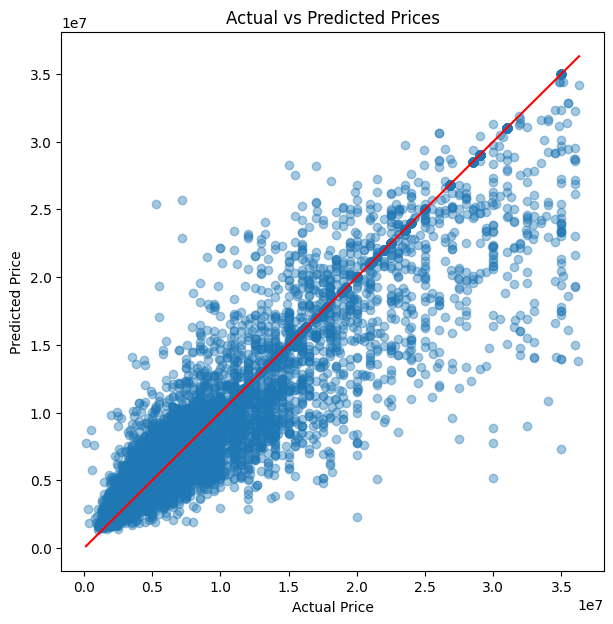

In [205]:
plt.figure(figsize=(7,7))

plt.scatter(y_true, y_pred, alpha=0.4)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [206]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
4,num__carpet_area_sqft,0.549617
1,num__Bathroom,0.164233
55,cat__location_new-delhi,0.043126
0,num__Floor,0.036751
48,cat__location_mumbai,0.028706
28,cat__location_gurgaon,0.024920
2,num__Balcony,0.016157
102,"cat__overlooking_Garden/Park, Main Road",0.013484
11,cat__location_bangalore,0.012681
41,cat__location_kolkata,0.012232


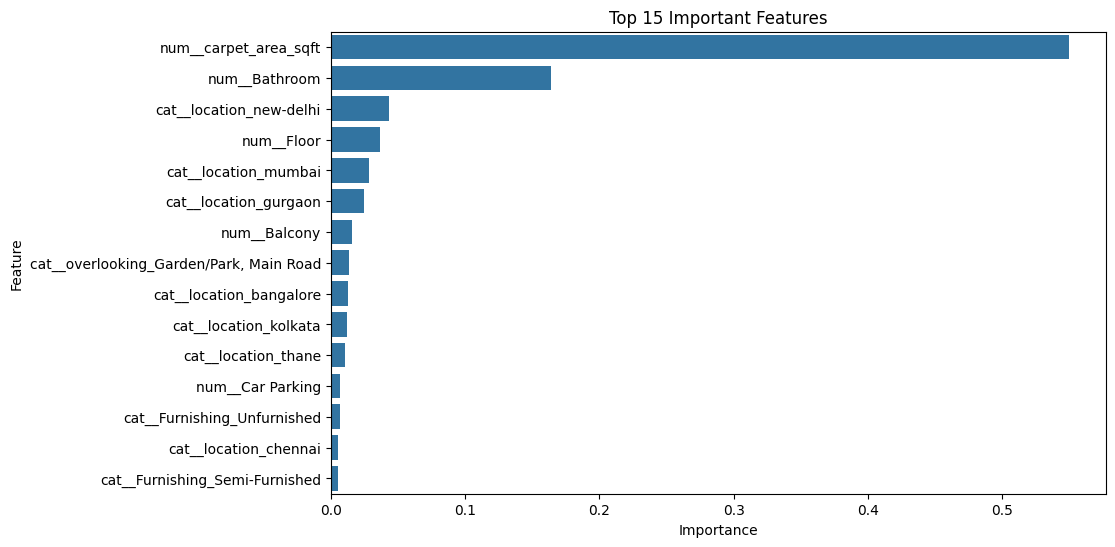

In [207]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

## Saving the Best Model

In [208]:
import joblib

In [209]:
joblib.dump(rf_model, "house_price_random_forest.pkl")

['house_price_random_forest.pkl']

In [210]:
loaded_model = joblib.load("house_price_random_forest.pkl")

In [211]:
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [212]:
loaded_model.predict(X_test[:5])

array([15.97103704, 15.21774346, 15.06897146, 15.82432693, 15.46984235])

In [213]:
rf_model.predict(X_test[:5])
loaded_model.predict(X_test[:5])

array([15.97103704, 15.21774346, 15.06897146, 15.82432693, 15.46984235])

## Model Comparison

The performance of Linear Regression and Random Forest Regressor was compared using MAE, RMSE, and R² score.

In [214]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [2958585.122368463, 828733.0157334295],
    "RMSE": [8735113.182659885, 2073019.5006804718],
    "R2": [-0.2759457253839124, 0.9281375692665951]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,2.958585e+06,8.735113e+06,-0.275946
1,Random Forest,8.287330e+05,2.073020e+06,0.928138


In [215]:
print("Original:", rf_model.predict(X_test[:5]))
print("Loaded :", loaded_model.predict(X_test[:5]))

Original: [15.97103704 15.21774346 15.06897146 15.82432693 15.46984235]
Loaded : [15.97103704 15.21774346 15.06897146 15.82432693 15.46984235]


# Conclusion

This project aimed to predict house prices using machine learning techniques.

The dataset was cleaned by handling missing values, extracting numerical features, removing unnecessary columns, and reducing the effect of extreme outliers.

Two regression models were trained:

- Linear Regression
- Random Forest Regressor

Linear Regression achieved poor performance because house prices have complex non-linear relationships with the available features.

Random Forest Regressor significantly improved the prediction accuracy and achieved:

- MAE = 828,733
- RMSE = 2,073,019
- R² = 0.928

Therefore, Random Forest was selected as the best-performing model for this dataset.

# Thank You

## End of Project